In [1]:
import numpy as np
import torch
from torch import nn
import matplotlib.pyplot as plt
import scipy
from sandbox.jordan5 import setup_device
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from sandbox.jordan8 import *

import json

In [2]:
device = setup_device()

torch.manual_seed(0)
np.random.seed(0)

# Training from scratch

In [3]:
model = JordanNet(encode_dim=32)

training_dimensions = [4, 6, 9, 12, 15, 28]
for d in training_dimensions:
    model.add_dimension(d)

training_dataset = generate_training_datasets(matrices_per_class=2000,
                                              dimensions=training_dimensions)

model = train_jordan_net(
    model,
    training_dataset,
    num_epochs=100, 
    batch_size=64,
    lr=1e-3,
    device=device,
    train_transformer=True,
    patience=3,
)

Generating class with d=4, max_block_size=1...Done.
Generating class with d=4, max_block_size=2...Done.
Generating class with d=4, max_block_size=3...Done.
Generating class with d=4, max_block_size=4...Done.
Generating class with d=6, max_block_size=1...Done.
Generating class with d=6, max_block_size=2...Done.
Generating class with d=6, max_block_size=3...Done.
Generating class with d=6, max_block_size=4...Done.
Generating class with d=6, max_block_size=5...Done.
Generating class with d=6, max_block_size=6...Done.
Generating class with d=9, max_block_size=1...Done.
Generating class with d=9, max_block_size=2...Done.
Generating class with d=9, max_block_size=3...Done.
Generating class with d=9, max_block_size=4...Done.
Generating class with d=9, max_block_size=5...Done.
Generating class with d=9, max_block_size=6...Done.
Generating class with d=9, max_block_size=7...Done.
Generating class with d=9, max_block_size=8...Done.
Generating class with d=9, max_block_size=9...Done.
Generating c

c:\Users\micha\Documents\Studia\Magisterka\venv\Lib\site-packages\torch\nn\functional.py:3006: UserWarning: The operator 'aten::xlogy.OutTensor' is not currently supported on the DML backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at C:\__w\1\s\pytorch-directml-plugin\torch_directml\csrc\dml\dml_cpu_fallback.cpp:17.)
  reduced = torch.kl_div(input, target, reduction_enum, log_target=log_target)


Epoch [1/100] | Train Loss: 1.191655 | Val Loss: 1.490710
Epoch [2/100] | Train Loss: 0.921906 | Val Loss: 1.282964
Epoch [3/100] | Train Loss: 0.825236 | Val Loss: 1.049723
Epoch [4/100] | Train Loss: 0.750246 | Val Loss: 1.043703
Epoch [5/100] | Train Loss: 0.681573 | Val Loss: 0.843250
Epoch [6/100] | Train Loss: 0.621090 | Val Loss: 0.759959
Epoch [7/100] | Train Loss: 0.573820 | Val Loss: 0.684134
Epoch [8/100] | Train Loss: 0.540546 | Val Loss: 0.630091
Epoch [9/100] | Train Loss: 0.507561 | Val Loss: 0.605965
Epoch [10/100] | Train Loss: 0.474782 | Val Loss: 0.536175
Epoch [11/100] | Train Loss: 0.442503 | Val Loss: 0.509766
Epoch [12/100] | Train Loss: 0.419228 | Val Loss: 0.546974
Epoch [13/100] | Train Loss: 0.394135 | Val Loss: 0.458709
Epoch [14/100] | Train Loss: 0.370454 | Val Loss: 0.453028
Epoch [15/100] | Train Loss: 0.354486 | Val Loss: 0.434601
Epoch [16/100] | Train Loss: 0.343014 | Val Loss: 0.401510
Epoch [17/100] | Train Loss: 0.344684 | Val Loss: 0.460022
Epoch 

c:\Users\micha\Documents\Studia\Magisterka\sandbox\jordan8.py:434: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(filename))


# Tests

In [5]:
def run_test(model, d, matrices_per_class=1000, mode="random", eps=None, eps_range=None):
    model.eval()

    training_dataset = generate_training_datasets(
        matrices_per_class=matrices_per_class,
        dimensions=[d],
        mode=mode,
        eps=eps,
        eps_range=eps_range,
        device="cpu",
    )
    matrices, labels, features, masks, dists = training_dataset[d]
    loader = DataLoader(TensorDataset(features, labels, masks, dists), batch_size=64, shuffle=False)

    predicted_classes = []
    true_classes = labels.cpu().tolist()
    kl_avg = 0.0

    for batch_features, batch_labels, batch_masks, batch_dists in loader:
        batch_features = batch_features.to(device)
        batch_labels = batch_labels.to(device)
        batch_masks = batch_masks.to(device)
        batch_dists = batch_dists.to(device)

        logits = model(d, batch_features, masks=batch_masks)
        loss = kl_loss(logits, batch_dists)

        preds = torch.argmax(logits, dim=-1)
        predicted_classes += preds.cpu().tolist()
        kl_avg += loss.item() * batch_features.size(0)

    kl_avg /= len(loader.dataset)
    # print(f"Test KL Loss: {kl_avg:.6f}")

    return true_classes, predicted_classes, kl_avg

def test_jordan_net(model, d, matrices_per_class=1000, filename=None):
    if filename is None:
        filename = f"sandbox/jordan8_results/results_{d}.json"

    results = []

    for eps in [0.0, 1e-6, 1e-4, 1e-2, 1e-1, 1]:
        print(f"Testing with eps={eps}")
        true_classes, predicted_classes, kl_avg = run_test(model, d, matrices_per_class=matrices_per_class, mode="random", eps=eps)
        results.append({
            "eps": eps,
            "true_classes": true_classes,
            "predicted_classes": predicted_classes,
            "kl_avg": kl_avg,
        })
    
    print(f"Testing mode 'ortho'")
    true_classes, predicted_classes, kl_avg = run_test(model, d, matrices_per_class=matrices_per_class, mode="ortho", eps=0.0)
    results.append({
        "eps": "ortho",
        "true_classes": true_classes,
        "predicted_classes": predicted_classes,
        "kl_avg": kl_avg,
    })
    with open(filename, "w") as f:
        json.dump(results, f, indent=4)
    
def visualize_test_results(d, filename):
    with open(filename, "r") as f:
        results = json.load(f) 
    
    for result in results:
        eps = result["eps"]
        true_classes = result["true_classes"]
        predicted_classes = result["predicted_classes"]
        
        cm = confusion_matrix(true_classes, predicted_classes, labels=list(range(d)))
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(1, d+1)))
        disp.plot(cmap=plt.cm.Blues)
        title = f"{'eps='+str(eps) if eps != 'ortho' else 'ortho'}. KL Loss: {result['kl_avg']:.6f}, accuracy: {np.trace(cm) / np.sum(cm):.4f}"
        plt.title(title)
        plt.show()
    
def print_test_results(d, filename):
    with open(filename, "r") as f:
        results = json.load(f)

    print(f"\nTest results for dimension {d}:") 
    
    for result in results:
        eps = result["eps"]
        true_classes = result["true_classes"]
        predicted_classes = result["predicted_classes"]
        
        cm = confusion_matrix(true_classes, predicted_classes, labels=list(range(d)))
        title = f"\t{'eps='+f'{eps:<10}' if eps != 'ortho' else 'ortho     '}\t KL Loss: {result['kl_avg']:.6f},\t accuracy: {np.trace(cm) / np.sum(cm):.4f}"
        print(title)

In [7]:
model = JordanNet(encode_dim=32)
training_dimensions = [4, 6, 9, 12, 15, 28]
for d in training_dimensions:
    model.add_dimension(d)
model.load_state_dict(torch.load(f"sandbox/model_jordan8.pth"))
model.to(device)
for d in training_dimensions:
    test_jordan_net(model, d, matrices_per_class=1000)

Testing with eps=0.0
Generating class with d=4, max_block_size=1...

C:\Users\micha\AppData\Local\Temp\ipykernel_11860\2942514706.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"sandbox/model_jordan8.pth

Done.
Generating class with d=4, max_block_size=2...Done.
Generating class with d=4, max_block_size=3...Done.
Generating class with d=4, max_block_size=4...Done.
Testing with eps=1e-06
Generating class with d=4, max_block_size=1...Done.
Generating class with d=4, max_block_size=2...Done.
Generating class with d=4, max_block_size=3...Done.
Generating class with d=4, max_block_size=4...Done.
Testing with eps=0.0001
Generating class with d=4, max_block_size=1...Done.
Generating class with d=4, max_block_size=2...Done.
Generating class with d=4, max_block_size=3...Done.
Generating class with d=4, max_block_size=4...Done.
Testing with eps=0.01
Generating class with d=4, max_block_size=1...Done.
Generating class with d=4, max_block_size=2...Done.
Generating class with d=4, max_block_size=3...Done.
Generating class with d=4, max_block_size=4...Done.
Testing with eps=0.1
Generating class with d=4, max_block_size=1...Done.
Generating class with d=4, max_block_size=2...Done.
Generating class wit

In [8]:
for d in training_dimensions:
    print_test_results(d, f"sandbox/jordan8_results/results_{d}.json")


Test results for dimension 4:
	eps=0.0       	 KL Loss: 0.119109,	 accuracy: 0.9998
	eps=1e-06     	 KL Loss: 0.023949,	 accuracy: 0.9998
	eps=0.0001    	 KL Loss: 0.441056,	 accuracy: 0.9978
	eps=0.01      	 KL Loss: 0.889933,	 accuracy: 0.7675
	eps=0.1       	 KL Loss: 2.262558,	 accuracy: 0.2580
	eps=1         	 KL Loss: 3.486830,	 accuracy: 0.2500
	ortho     	 KL Loss: 0.116585,	 accuracy: 1.0000

Test results for dimension 6:
	eps=0.0       	 KL Loss: 0.158252,	 accuracy: 0.9993
	eps=1e-06     	 KL Loss: 0.025318,	 accuracy: 1.0000
	eps=0.0001    	 KL Loss: 0.422977,	 accuracy: 0.9965
	eps=0.01      	 KL Loss: 0.999572,	 accuracy: 0.7125
	eps=0.1       	 KL Loss: 4.538933,	 accuracy: 0.1687
	eps=1         	 KL Loss: 6.962380,	 accuracy: 0.1667
	ortho     	 KL Loss: 0.156525,	 accuracy: 1.0000

Test results for dimension 9:
	eps=0.0       	 KL Loss: 0.244546,	 accuracy: 0.9990
	eps=1e-06     	 KL Loss: 0.022744,	 accuracy: 0.9998
	eps=0.0001    	 KL Loss: 0.428223,	 accuracy: 0.99

# Training + tests on additional dimensions

In [15]:
model = JordanNet(encode_dim=32).cpu()
pretrained_dimensions = [4, 6, 9, 12, 15, 28]
for d in pretrained_dimensions:
    model.add_dimension(d)

model.load_state_dict(torch.load(f"sandbox/model_jordan8.pth", map_location="cpu"))
model.to(device)

new_dimensions = [35, 33, 25, 23, 19, 13, 7]

for d in new_dimensions:
    model.add_dimension(d)
    training_dataset = generate_training_datasets(matrices_per_class=1000,
                                                dimensions=[d])
    model = train_jordan_net(
        model,
        training_dataset,
        num_epochs=50,
        batch_size=64,
        lr=1e-3,
        device=device,
        train_transformer=False)

Generating class with d=35, max_block_size=1...

C:\Users\micha\AppData\Local\Temp\ipykernel_11860\1608948895.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"sandbox/model_jordan8.pth

Done.
Generating class with d=35, max_block_size=2...Done.
Generating class with d=35, max_block_size=3...Done.
Generating class with d=35, max_block_size=4...Done.
Generating class with d=35, max_block_size=5...Done.
Generating class with d=35, max_block_size=6...Done.
Generating class with d=35, max_block_size=7...Done.
Generating class with d=35, max_block_size=8...Done.
Generating class with d=35, max_block_size=9...Done.
Generating class with d=35, max_block_size=10...Done.
Generating class with d=35, max_block_size=11...Done.
Generating class with d=35, max_block_size=12...Done.
Generating class with d=35, max_block_size=13...Done.
Generating class with d=35, max_block_size=14...Done.
Generating class with d=35, max_block_size=15...Done.
Generating class with d=35, max_block_size=16...Done.
Generating class with d=35, max_block_size=17...Done.
Generating class with d=35, max_block_size=18...Done.
Generating class with d=35, max_block_size=19...Done.
Generating class with d=35, ma

c:\Users\micha\Documents\Studia\Magisterka\sandbox\jordan8.py:434: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(filename))


Generating class with d=33, max_block_size=1...Done.
Generating class with d=33, max_block_size=2...Done.
Generating class with d=33, max_block_size=3...Done.
Generating class with d=33, max_block_size=4...Done.
Generating class with d=33, max_block_size=5...Done.
Generating class with d=33, max_block_size=6...Done.
Generating class with d=33, max_block_size=7...Done.
Generating class with d=33, max_block_size=8...Done.
Generating class with d=33, max_block_size=9...Done.
Generating class with d=33, max_block_size=10...Done.
Generating class with d=33, max_block_size=11...Done.
Generating class with d=33, max_block_size=12...Done.
Generating class with d=33, max_block_size=13...Done.
Generating class with d=33, max_block_size=14...Done.
Generating class with d=33, max_block_size=15...Done.
Generating class with d=33, max_block_size=16...Done.
Generating class with d=33, max_block_size=17...Done.
Generating class with d=33, max_block_size=18...Done.
Generating class with d=33, max_block

In [16]:
model = JordanNet(encode_dim=32).cpu()
pretrained_dimensions = [4, 6, 9, 12, 15, 28]
for d in pretrained_dimensions:
    model.add_dimension(d)

new_dimensions = [35, 33, 25, 23, 19, 13, 7]

for d in new_dimensions:
    model.add_dimension(d)


model.load_state_dict(torch.load(f"sandbox/model_jordan8_modified.pth", map_location="cpu"))
model.to(device)

C:\Users\micha\AppData\Local\Temp\ipykernel_11860\3686752702.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"sandbox/model_jordan8_mo

JordanNet(
  (encoders): ModuleDict(
    (4): MatrixEncoder(
      (net): Sequential(
        (0): Linear(in_features=16, out_features=128, bias=True)
        (1): ReLU()
        (2): Linear(in_features=128, out_features=128, bias=True)
        (3): ReLU()
        (4): Linear(in_features=128, out_features=128, bias=True)
        (5): ReLU()
        (6): Linear(in_features=128, out_features=32, bias=True)
      )
    )
    (6): MatrixEncoder(
      (net): Sequential(
        (0): Linear(in_features=36, out_features=128, bias=True)
        (1): ReLU()
        (2): Linear(in_features=128, out_features=128, bias=True)
        (3): ReLU()
        (4): Linear(in_features=128, out_features=128, bias=True)
        (5): ReLU()
        (6): Linear(in_features=128, out_features=32, bias=True)
      )
    )
    (9): MatrixEncoder(
      (net): Sequential(
        (0): Linear(in_features=81, out_features=128, bias=True)
        (1): ReLU()
        (2): Linear(in_features=128, out_features=128, bias

In [17]:
for d in new_dimensions:
    test_jordan_net(model, d, matrices_per_class=500)

Testing with eps=0.0
Generating class with d=35, max_block_size=1...Done.
Generating class with d=35, max_block_size=2...Done.
Generating class with d=35, max_block_size=3...Done.
Generating class with d=35, max_block_size=4...Done.
Generating class with d=35, max_block_size=5...Done.
Generating class with d=35, max_block_size=6...Done.
Generating class with d=35, max_block_size=7...Done.
Generating class with d=35, max_block_size=8...Done.
Generating class with d=35, max_block_size=9...Done.
Generating class with d=35, max_block_size=10...Done.
Generating class with d=35, max_block_size=11...Done.
Generating class with d=35, max_block_size=12...Done.
Generating class with d=35, max_block_size=13...Done.
Generating class with d=35, max_block_size=14...Done.
Generating class with d=35, max_block_size=15...Done.
Generating class with d=35, max_block_size=16...Done.
Generating class with d=35, max_block_size=17...Done.
Generating class with d=35, max_block_size=18...Done.
Generating class

In [18]:
for d in new_dimensions:
    print_test_results(d, f"sandbox/jordan8_results/results_{d}.json")


Test results for dimension 35:
	eps=0.0       	 KL Loss: 1.010245,	 accuracy: 0.6210
	eps=1e-06     	 KL Loss: 0.159461,	 accuracy: 0.9630
	eps=0.0001    	 KL Loss: 0.818479,	 accuracy: 0.9385
	eps=0.01      	 KL Loss: 2.563886,	 accuracy: 0.2145
	eps=0.1       	 KL Loss: 31.347702,	 accuracy: 0.0178
	eps=1         	 KL Loss: 1.624396,	 accuracy: 0.0286
	ortho     	 KL Loss: 2.089039,	 accuracy: 0.3687

Test results for dimension 33:
	eps=0.0       	 KL Loss: 1.290856,	 accuracy: 0.4794
	eps=1e-06     	 KL Loss: 0.071254,	 accuracy: 0.9914
	eps=0.0001    	 KL Loss: 0.392460,	 accuracy: 0.9736
	eps=0.01      	 KL Loss: 1.852519,	 accuracy: 0.1484
	eps=0.1       	 KL Loss: 17.764937,	 accuracy: 0.0195
	eps=1         	 KL Loss: 1.558157,	 accuracy: 0.0303
	ortho     	 KL Loss: 1.913531,	 accuracy: 0.3458

Test results for dimension 25:
	eps=0.0       	 KL Loss: 0.960773,	 accuracy: 0.5619
	eps=1e-06     	 KL Loss: 0.074027,	 accuracy: 0.9842
	eps=0.0001    	 KL Loss: 0.477382,	 accuracy:

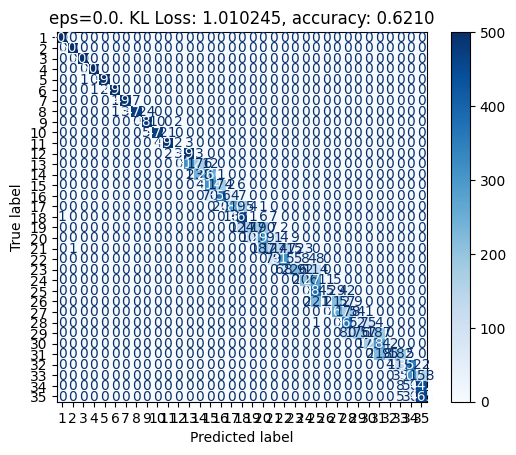

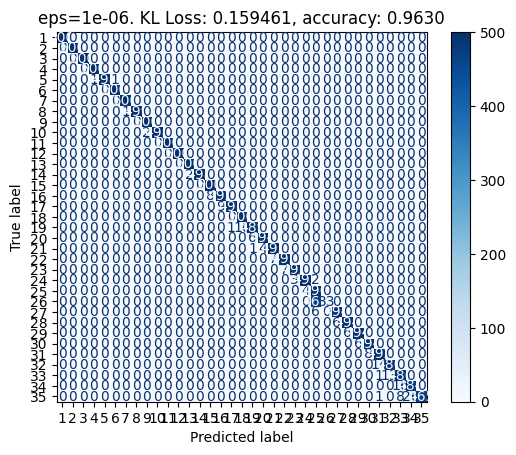

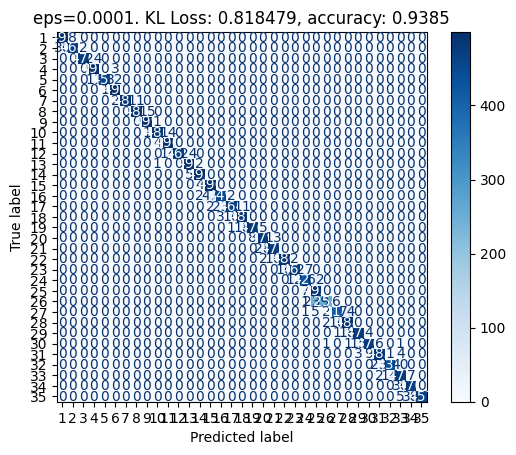

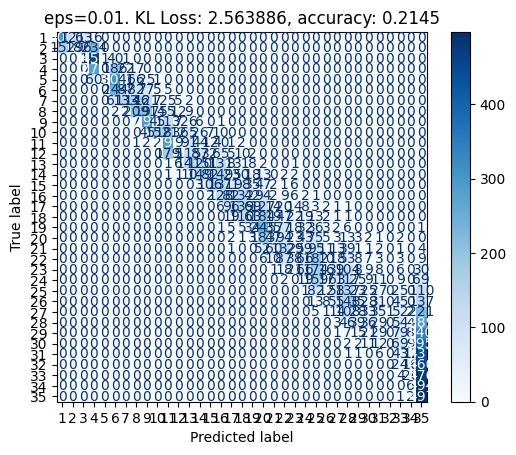

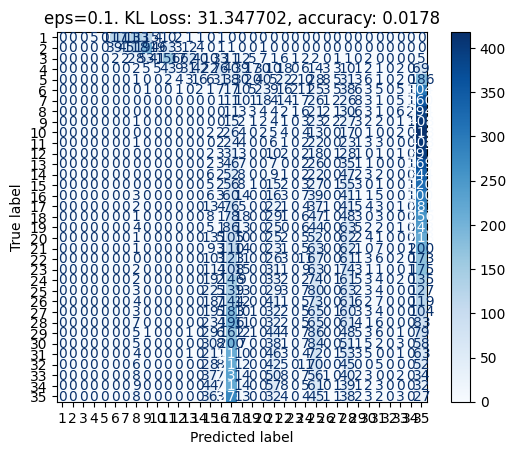

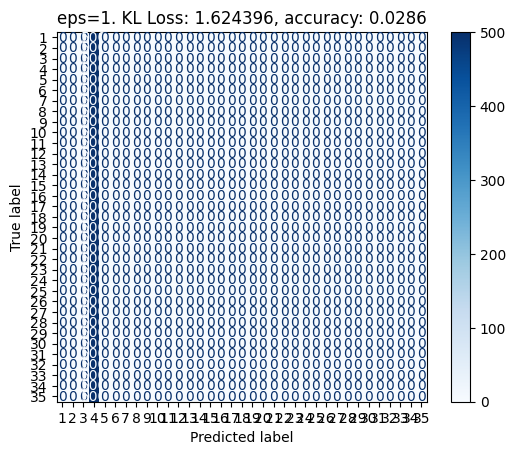

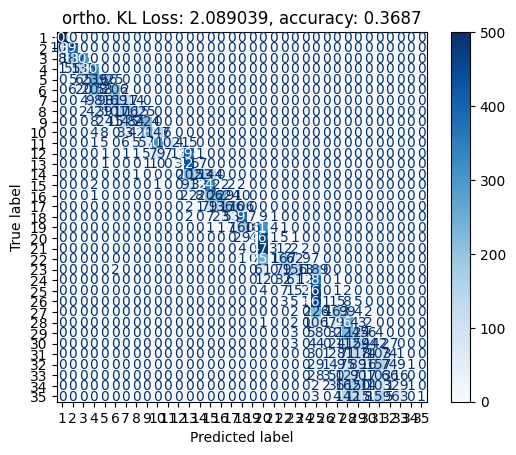

In [19]:
visualize_test_results(35, f"sandbox/jordan8_results/results_35.json")

# Test results comparison

In [20]:
import os
import json
import matplotlib.pyplot as plt
from collections import defaultdict

def plot_model_results(folder_path, epsilons, d_train):
    """
    Parses result JSONs and plots KL-loss and Accuracy across dimensions d.
    """
    # Data structure: { epsilon: { d_value: {'kl': [], 'acc': []} } }
    data = defaultdict(lambda: defaultdict(lambda: {'kl': None, 'acc': None}))
    
    # 1. Data Extraction
    for filename in os.listdir(folder_path):
        if filename.startswith("results_") and filename.endswith(".json"):
            # Extract d from filename (e.g., results_10.json -> 10)
            try:
                d = int(filename.split('_')[1].split('.')[0])
            except ValueError:
                continue
                
            file_path = os.path.join(folder_path, filename)
            with open(file_path, 'r') as f:
                results = json.load(f)
            
            for entry in results:
                curr_eps = entry.get("eps")
                
                # Only process if this epsilon is in our target list
                if curr_eps in epsilons:
                    # Calculate Accuracy
                    preds = entry.get("predicted_classes", [])
                    trues = entry.get("true_classes", [])
                    acc = sum(1 for p, t in zip(preds, trues) if p == t) / len(trues) if trues else 0
                    
                    # Store values
                    data[curr_eps][d]['kl'] = entry.get("kl_avg")
                    data[curr_eps][d]['acc'] = acc

    # 2. Preparation for Plotting
    # Sort epsilons for consistent legend order
    sorted_eps = sorted(epsilons, key=lambda x: (str(type(x)), x))
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    for eps in sorted_eps:
        # Sort by d to ensure lines connect correctly
        sorted_ds = sorted(data[eps].keys())
        kl_vals = [data[eps][d]['kl'] for d in sorted_ds]
        acc_vals = [data[eps][d]['acc'] for d in sorted_ds]
        
        label = f"$\epsilon$ = {eps}" if eps != 'ortho' else "Ortho"
        
        ax1.plot(sorted_ds, kl_vals, marker='o', label=label)
        ax2.plot(sorted_ds, acc_vals, marker='s', label=label)

    # 3. Mark "Base Training Dimensions"
    # We'll use a vertical span (shaded area) or lines to highlight training d
    for ax in [ax1, ax2]:
        for i, d_val in enumerate(d_train):
            # Adding a vertical dashed line for each training dimension
            ax.axvline(x=d_val, color='gray', linestyle='--', alpha=0.5, 
                       label="Train Dim" if i == 0 else "")
            # Adding a subtle highlight/text
            ax.text(d_val, ax.get_ylim()[0], f' $d={d_val}$', 
                    rotation=90, verticalalignment='bottom', fontsize=8, color='gray')

    # Formatting
    ax1.set_title("Average KL-Loss vs Dimension ($d$)")
    ax1.set_xlabel("Dimension ($d$)")
    ax1.set_ylabel("KL Loss")
    ax1.legend()
    ax1.grid(True, which='both', linestyle=':', alpha=0.5)

    ax2.set_title("Accuracy vs Dimension ($d$)")
    ax2.set_xlabel("Dimension ($d$)")
    ax2.set_ylabel("Accuracy Score")
    ax2.legend()
    ax2.grid(True, which='both', linestyle=':', alpha=0.5)

    plt.tight_layout()
    plt.show()

# Example Usage:
# plot_model_results('./results_folder', [0.1, 0.5, 'ortho'], [10, 50])

In [21]:
pretrained_dimensions = [4, 6, 9, 12, 15, 28]

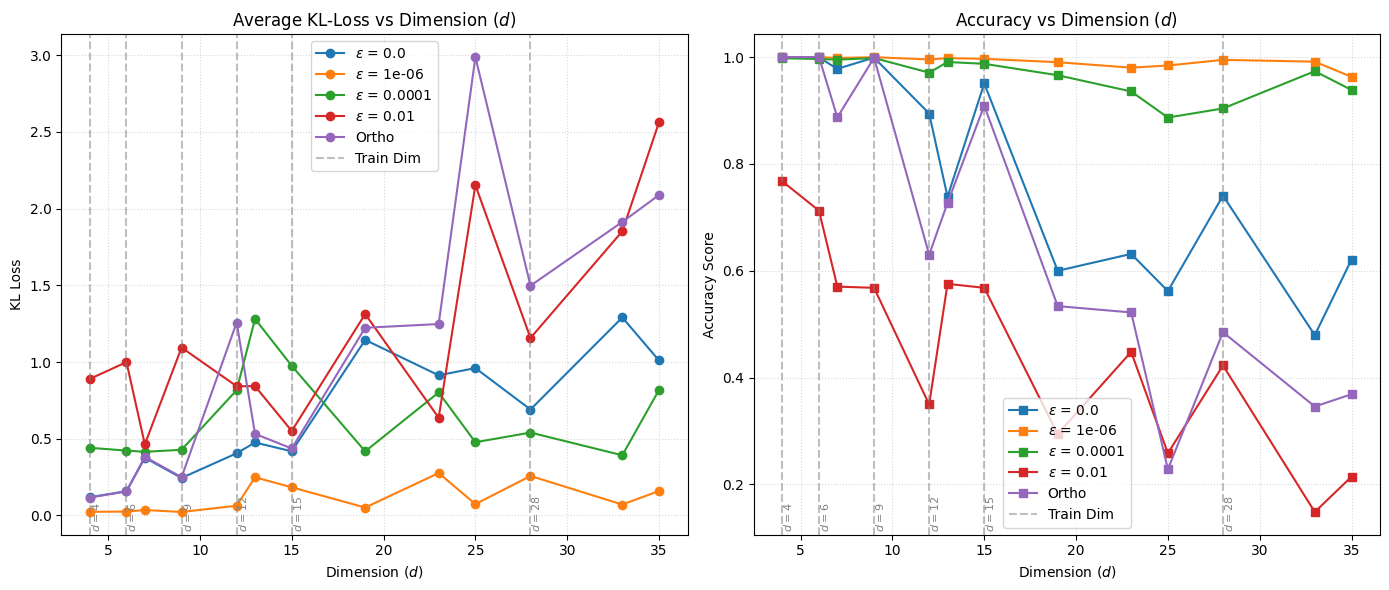

In [22]:
plot_model_results('./sandbox/jordan8_results', [0.0, 1e-6, 1e-4, 1e-2, 'ortho'], pretrained_dimensions)

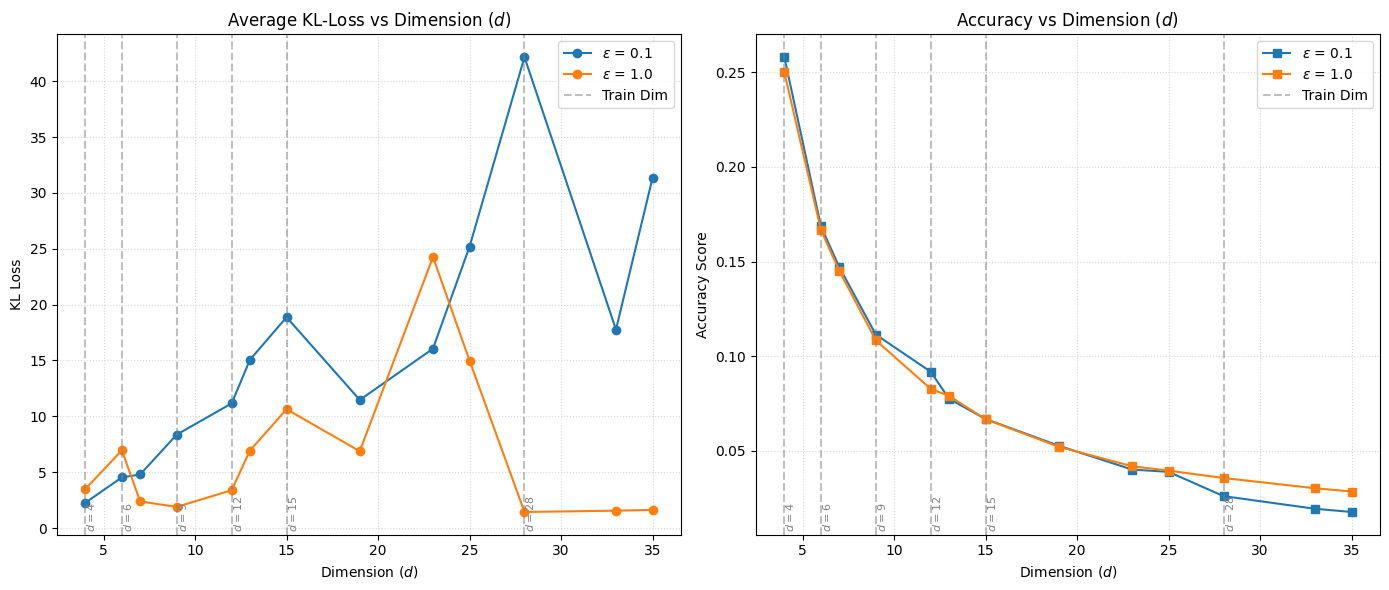

In [23]:
plot_model_results('./sandbox/jordan8_results', [0.1, 1.0], pretrained_dimensions)

In [3]:
def _load_state(path):
    sd = torch.load(path, map_location="cpu")
    # handle common checkpoint wrappers
    if isinstance(sd, dict) and ("state_dict" in sd or "model_state_dict" in sd):
        sd = sd.get("state_dict", sd.get("model_state_dict"))
    return sd

def _is_transformer_key(k):
    kl = k.lower()
    tokens = ("transformer", "transf", "encoder", "attn", "self_attn", "multihead", "mha", "ffn", "feed_forward")
    return any(t in kl for t in tokens)

p1 = "sandbox/model_jordan8.pth"
p2 = "sandbox/model_jordan8_modified.pth"

sd1 = _load_state(p1)
sd2 = _load_state(p2)

keys1 = set(sd1.keys())
keys2 = set(sd2.keys())

# collect transformer-related keys present in either checkpoint
t_keys = sorted(k for k in (keys1 | keys2) if _is_transformer_key(k))

if not t_keys:
    print("No transformer-related parameter names found in checkpoints.")
else:
    all_identical = True
    for k in t_keys:
        in1 = k in sd1
        in2 = k in sd2
        if not (in1 and in2):
            print(f"Mismatch presence: '{k}' only in", p1 if in1 else p2)
            all_identical = False
            continue

        a = sd1[k]
        b = sd2[k]
        if a.shape != b.shape:
            print(f"Shape differs for '{k}': {a.shape} vs {b.shape}")
            all_identical = False
            continue

        equal = torch.equal(a, b)
        max_abs = (a - b).abs().max().item() if a.numel() > 0 else 0.0
        mean_abs = (a - b).abs().mean().item() if a.numel() > 0 else 0.0
        status = "IDENTICAL" if equal else "DIFFER"
        print(f"{status}: {k} | max_abs={max_abs:.6e}, mean_abs={mean_abs:.6e}")
        if not equal:
            all_identical = False


IDENTICAL: encoders.12.net.0.bias | max_abs=0.000000e+00, mean_abs=0.000000e+00
IDENTICAL: encoders.12.net.0.weight | max_abs=0.000000e+00, mean_abs=0.000000e+00
IDENTICAL: encoders.12.net.2.bias | max_abs=0.000000e+00, mean_abs=0.000000e+00
IDENTICAL: encoders.12.net.2.weight | max_abs=0.000000e+00, mean_abs=0.000000e+00
IDENTICAL: encoders.12.net.4.bias | max_abs=0.000000e+00, mean_abs=0.000000e+00
IDENTICAL: encoders.12.net.4.weight | max_abs=0.000000e+00, mean_abs=0.000000e+00
IDENTICAL: encoders.12.net.6.bias | max_abs=0.000000e+00, mean_abs=0.000000e+00
IDENTICAL: encoders.12.net.6.weight | max_abs=0.000000e+00, mean_abs=0.000000e+00
Mismatch presence: 'encoders.13.net.0.bias' only in sandbox/model_jordan8_modified.pth
Mismatch presence: 'encoders.13.net.0.weight' only in sandbox/model_jordan8_modified.pth
Mismatch presence: 'encoders.13.net.2.bias' only in sandbox/model_jordan8_modified.pth
Mismatch presence: 'encoders.13.net.2.weight' only in sandbox/model_jordan8_modified.pth


C:\Users\micha\AppData\Local\Temp\ipykernel_17552\3512677630.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(path, map_location="cpu")
